In [1]:
import os
import shutil

dossier_models = "/content/drive/MyDrive/tp_IA/projetCIP14/models"
if os.path.exists(dossier_models):
    shutil.rmtree(dossier_models)
    print(" Anciens modèles supprimés avec succès !")
os.makedirs(dossier_models, exist_ok=True)

 Anciens modèles supprimés avec succès !


In [2]:
import pandas as pd
import os
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# --- CONFIGURATION ---
from google.colab import drive
drive.mount('/content/drive')

# --- CONFIGURATION COMPLÈTE ---
class Args:
    def __init__(self):
        # 1. Les chemins (Google Drive)
        self.projet_path = "/content/drive/MyDrive/tp_IA/projetCIP14/"
        self.file = self.projet_path + "BD_arbres_final_complet.csv"

        self.path_preprocessor = self.projet_path + "models/preprocessor_tempete.pkl"
        self.path_modele = self.projet_path + "models/modele_tempete.pkl"

        # 2. Les variables de l'IA (Ton ajout est bien là !)
        self.X = ["haut_tronc", "haut_tot", "tronc_diam", "clc_nbr_diag"]
        self.Y = "fk_arb_etat"

        # 3. Les paramètres d'exécution (Ceux qui manquaient !)
        self.models = ["RandomForestClassifier", "HistGradientBoostingClassifier"]
        self.save_model = True
        self.grid_search = True

args = Args()
os.makedirs(args.projet_path + "models", exist_ok=True)

# --- CHARGEMENT ET NETTOYAGE ---
data = pd.read_csv(args.file, encoding='utf-8')

# 1. On supprime les lignes où l'état de l'arbre n'est pas renseigné
data = data.dropna(subset=[args.Y])

# 2. LA MAGIE EST ICI : On regroupe les états en 0 (Sûr) et 1 (Danger)
def definir_risque(etat):
    etat = str(etat).upper().strip() # On met tout en majuscule pour éviter les erreurs
    if etat == 'EN PLACE':
        return 'SÛR' # Ou 0
    else:
        # Si c'est Essouché, Remplacé, Abattu, etc...
        return 'DANGER' # Ou 1

# On applique cette règle à notre colonne cible
data[args.Y] = data[args.Y].apply(definir_risque)

# Ensuite on garde uniquement les colonnes utiles
colonnes_utiles = args.X + [args.Y]
data = data.dropna(subset=colonnes_utiles)

# ... (Le reste de l'étape 1 avec le train_test_split et le preprocessor) ...

#  SÉPARATION DES DONNÉES
X = data[args.X]
y = data[args.Y]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  ENCODAGE ET NORMALISATION
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


joblib.dump(preprocessor, args.path_preprocessor)
print("préprocesseur sauvegardé ")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
préprocesseur sauvegardé 


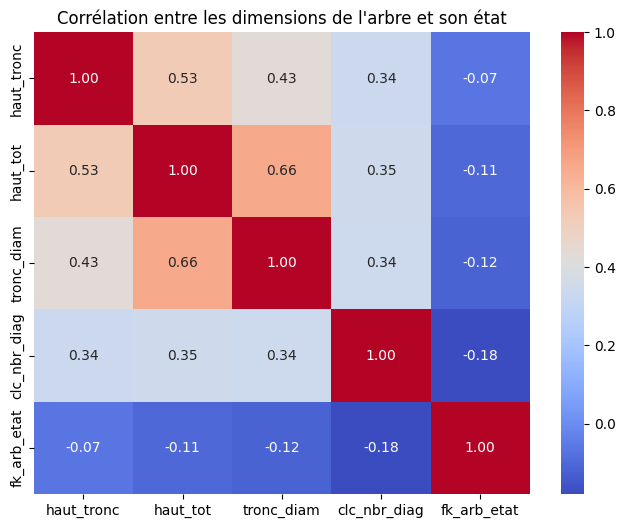

Tableau des corrélations :
              haut_tronc  haut_tot  tronc_diam  clc_nbr_diag  fk_arb_etat
haut_tronc      1.000000  0.526506    0.431174      0.335884    -0.065584
haut_tot        0.526506  1.000000    0.658787      0.347572    -0.105233
tronc_diam      0.431174  0.658787    1.000000      0.342241    -0.118750
clc_nbr_diag    0.335884  0.347572    0.342241      1.000000    -0.180380
fk_arb_etat    -0.065584 -0.105233   -0.118750     -0.180380     1.000000


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On crée une copie temporaire des données pour ne pas casser la suite de ton code
df_graphe = data.copy()

# 2. On transforme la colonne texte (état de l'arbre) en codes numériques (0, 1, 2...)
df_graphe[args.Y] = df_graphe[args.Y].astype('category').cat.codes

# 3. On génère le graphe
plt.figure(figsize=(8, 6))

# On calcule la corrélation sur notre DataFrame temporaire contenant que des nombres
matrice_corr = df_graphe[args.X + [args.Y]].corr()

sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélation entre les dimensions de l'arbre et son état")
plt.show()

# Pour le rapport (Le "Tableau") :
print("Tableau des corrélations :")
print(matrice_corr)

Démarrage de GridSearchCV...

 Entraînement : Random Forest 
 Meilleurs hyperparamètres RF : {'max_depth': None, 'n_estimators': 50}

 Entraînement : HistGradientBoosting 
 Meilleurs hyperparamètres HGB : {'max_depth': None, 'max_iter': 100}
Rapport de classification :

              precision    recall  f1-score   support

      DANGER       0.29      0.42      0.34       155
         SÛR       0.94      0.89      0.91      1496

    accuracy                           0.85      1651
   macro avg       0.61      0.66      0.63      1651
weighted avg       0.88      0.85      0.86      1651



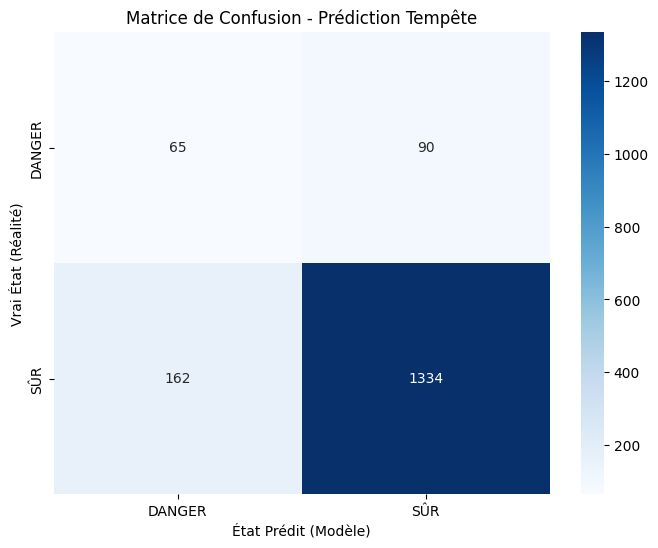


 Étape 2 validée : Modèle final sauvegardé sous '/content/drive/MyDrive/tp_IA/projetCIP14/models/modele_tempete.pkl' !


In [4]:
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Dictionnaire pour stocker les modèles entraînés
modeles_entraines = {}

if args.grid_search:
    print("Démarrage de GridSearchCV...\n")

    # 1. Test du RandomForest
    if "RandomForestClassifier" in args.models:
        print(" Entraînement : Random Forest ")
        rf = RandomForestClassifier(random_state=42, class_weight='balanced')

        param_grid_rf = {
            'n_estimators': [50, 100],
            'max_depth': [None, 10]
        }
        grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
        grid_rf.fit(X_train_processed, y_train)

        modeles_entraines["RandomForestClassifier"] = grid_rf.best_estimator_
        print(f" Meilleurs hyperparamètres RF : {grid_rf.best_params_}")

    # 2. Test du HistGradientBoosting
    if "HistGradientBoostingClassifier" in args.models:
        print("\n Entraînement : HistGradientBoosting ")

        hgb = HistGradientBoostingClassifier(random_state=42)
        param_grid_hgb = {
            'max_iter': [100],
            'max_depth': [None, 10]
        }
        grid_hgb = GridSearchCV(hgb, param_grid_hgb, cv=3, scoring='accuracy')

        try:
            # On force la conversion en tableau dense classique au cas où
            X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
            grid_hgb.fit(X_train_dense, y_train)
            modeles_entraines["HistGradientBoostingClassifier"] = grid_hgb.best_estimator_
            print(f" Meilleurs hyperparamètres HGB : {grid_hgb.best_params_}")
        except Exception as e:
            print(f" HGB a échoué (probablement un souci de format de matrice) : {e}")

#  ÉVALUATION DU MEILLEUR MODÈLE
if "RandomForestClassifier" in modeles_entraines:
    modele_final = modeles_entraines["RandomForestClassifier"]

    y_pred = modele_final.predict(X_test_processed)

    # 1. Le Tableau
    print("Rapport de classification :\n")
    print(classification_report(y_test, y_pred))

    # 2. Le Graphe
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=modele_final.classes_, yticklabels=modele_final.classes_)
    plt.title('Matrice de Confusion - Prédiction Tempête')
    plt.ylabel('Vrai État (Réalité)')
    plt.xlabel('État Prédit (Modèle)')
    plt.show()

    # SAUVEGARDE DU MODÈLE S
    if getattr(args, 'save_model', False):
        chemin_modele = getattr(args, 'path_modele', 'models/modele_tempete.pkl')
        joblib.dump(modele_final, chemin_modele)
        print(f"\n Étape 2 validée : Modèle final sauvegardé sous '{chemin_modele}' !")
else:
    print("\n Aucun modèleentraîné")

In [5]:
import pandas as pd
import numpy as np
import joblib
import os

def evaluer_foret(liste_arbres):
    chemin_preprocessor = args.path_preprocessor
    chemin_modele = args.path_modele

    # 1. Vérification de sécurité
    if not os.path.exists(chemin_preprocessor) or not os.path.exists(chemin_modele):
        print(f" Erreur : Je ne trouve pas les fichiers .pkl aux emplacements suivants :")
        print(f"1. {chemin_preprocessor}")
        print(f"2. {chemin_modele}")
        return

    # 2. Chargement des modèles depuis le Drive
    preprocessor = joblib.load(chemin_preprocessor)
    modele = joblib.load(chemin_modele)

    # 3. Conversion en DataFrame
    df_arbres = pd.DataFrame(liste_arbres)

    # 4. Prétraitement et Prédictions
    donnees_transformees = preprocessor.transform(df_arbres)
    predictions = modele.predict(donnees_transformees)
    probabilites = modele.predict_proba(donnees_transformees)

    # 5. Affichage propre des résultats
    print("RÉSULTATS DU SYSTÈME D'ALERTE TEMPÊTE ")

    for i in range(len(predictions)):
        pred = predictions[i]
        index_classe = np.where(modele.classes_ == pred)[0][0]
        confiance = probabilites[i][index_classe] * 100

        print(f"\n ARBRE N°{i+1}")
        print(f"   Données saisies : {liste_arbres[i]}")
        print(f"    État prévu : {pred}")
        print(f"    Indice de fiabilité : {confiance:.2f}%")

#  LE TEST
arbres_a_tester = [
    {"haut_tronc": 2.5, "haut_tot": 15.0, "tronc_diam": 45.0, "clc_nbr_diag": 0},
    {"haut_tronc": 5.0, "haut_tot": 25.0, "tronc_diam": 20.0, "clc_nbr_diag": 4},
    {"haut_tronc": 1.5, "haut_tot": 8.0,  "tronc_diam": 80.0, "clc_nbr_diag": 1}
]

evaluer_foret(arbres_a_tester)

RÉSULTATS DU SYSTÈME D'ALERTE TEMPÊTE 

 ARBRE N°1
   Données saisies : {'haut_tronc': 2.5, 'haut_tot': 15.0, 'tronc_diam': 45.0, 'clc_nbr_diag': 0}
    État prévu : SÛR
    Indice de fiabilité : 100.00%

 ARBRE N°2
   Données saisies : {'haut_tronc': 5.0, 'haut_tot': 25.0, 'tronc_diam': 20.0, 'clc_nbr_diag': 4}
    État prévu : SÛR
    Indice de fiabilité : 94.00%

 ARBRE N°3
   Données saisies : {'haut_tronc': 1.5, 'haut_tot': 8.0, 'tronc_diam': 80.0, 'clc_nbr_diag': 1}
    État prévu : SÛR
    Indice de fiabilité : 62.00%


📊 TOP DES VARIABLES LIÉES AU RISQUE DE CHUTE
cible_risque     1.000000
a_abattre        0.818618
clc_nbr_diag     0.180380
fk_prec_estim    0.161983
age_predit       0.159768
age_final        0.156617
tronc_diam       0.154357
haut_tot         0.144287
age_estim        0.103095
Longitude        0.103023
X                0.102881
haut_tronc       0.095264
Y                0.032479
Latitude         0.032027
id_arbre        -0.103581
OBJECTID        -0.208638
Name: cible_risque, dtype: float64


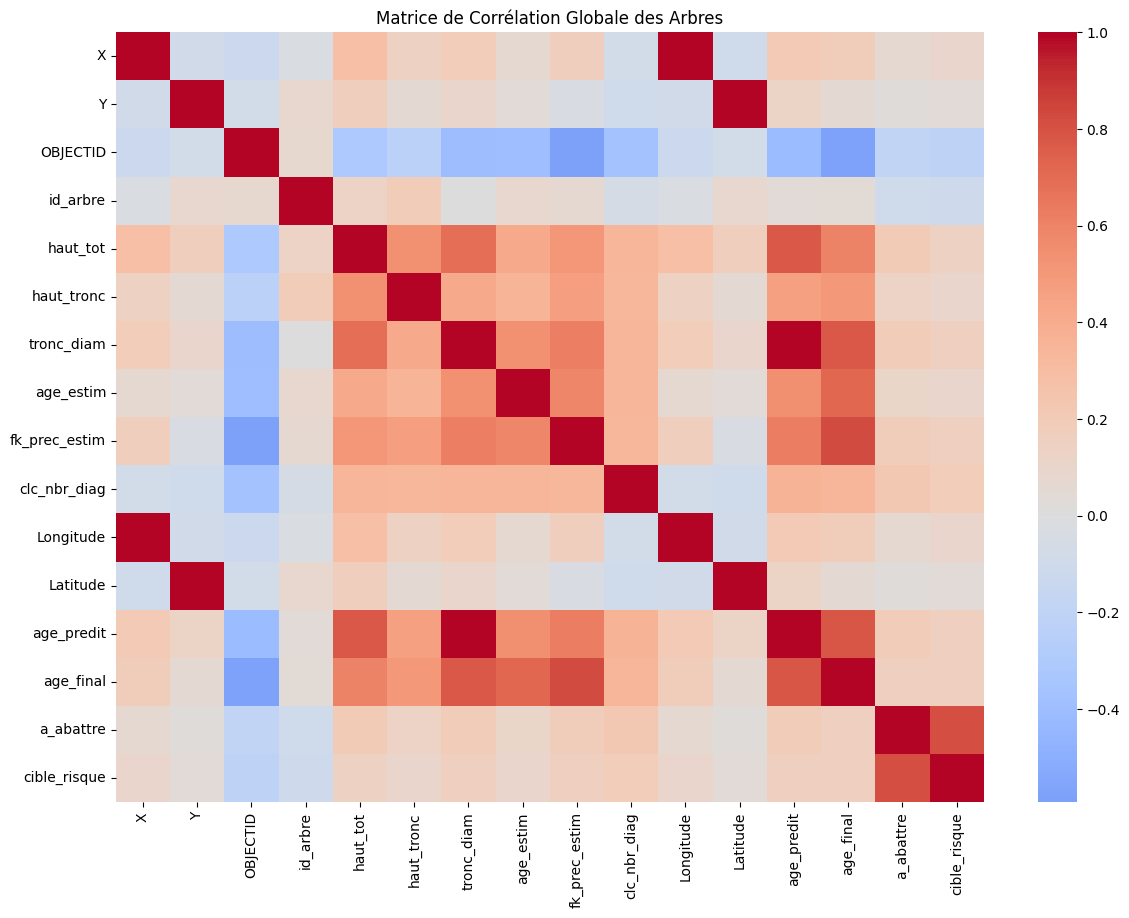

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Charger les données (On utilise ton chemin exact)
chemin_csv = "/content/drive/MyDrive/tp_IA/projetCIP14/BD_arbres_final_complet.csv"
data = pd.read_csv(chemin_csv, encoding='utf-8')

# 2. Préparer la cible (0 = SÛR, 1 = DANGER)
def definir_risque(etat):
    etat = str(etat).upper().strip()
    if etat == 'EN PLACE':
        return 0
    else:
        return 1

# On crée une colonne temporaire purement numérique pour l'analyse
if 'fk_arb_etat' in data.columns:
    data['cible_risque'] = data['fk_arb_etat'].apply(definir_risque)
else:
    print("Erreur: La colonne 'fk_arb_etat' est introuvable.")

# 3. Ne garder QUE les colonnes qui contiennent des nombres
colonnes_numeriques = data.select_dtypes(include=['float64', 'int64'])

# 4. Calcul de la matrice de corrélation
matrice_corr = colonnes_numeriques.corr()

# 5. Affichage sous forme de texte (Le plus utile !)
print(" TOP DES VARIABLES LIÉES AU RISQUE DE CHUTE")
# On regarde ce qui est le plus corrélé avec notre nouvelle colonne 'cible_risque'
corr_cible = matrice_corr['cible_risque'].sort_values(ascending=False)
print(corr_cible)

# 6. Affichage visuel (Heatmap)
plt.figure(figsize=(14, 10))
# On n'affiche pas les chiffres dans les cases (annot=False) car avec tout le CSV, ce serait illisible
sns.heatmap(matrice_corr, annot=False, cmap='coolwarm', center=0)
plt.title("Matrice de Corrélation Globale des Arbres")
plt.show()